## REGRESSION - Fitting a plane to the given data

Fitted plane: z = 2.0000 * x + 3.0000 * y + -5.0000
Mean Squared Error: 0.0000


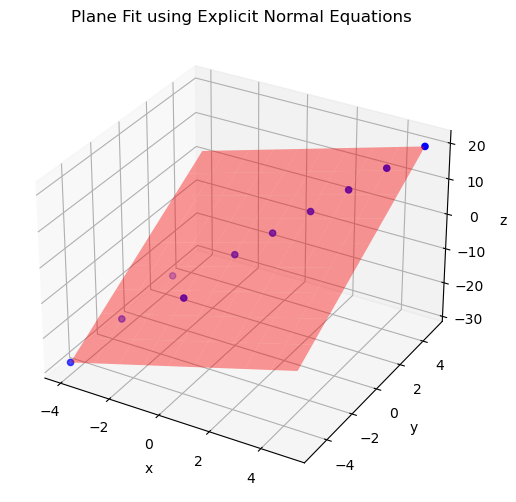

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Reproducibility
rng = np.random.default_rng(2026)


def fit_plane_normal_equation(x, y, z):
    """
    Fit a plane z = a*x + b*y + c to data (x, y, z) using the
    EXPLICIT normal equations of least-squares regression (derived by
    setting the partial derivatives of the sum-of-squared-errors
    with respect to a, b, and c to zero).

    For z = a*x + b*y + c, minimizing
        S = sum((z_i - a*x_i - b*y_i - c)^2)
    w.r.t. a, b, c gives the three normal equations:

        (1) sum(x*z) = a*sum(x^2)  + b*sum(x*y) + c*sum(x)
        (2) sum(y*z) = a*sum(x*y)  + b*sum(y^2) + c*sum(y)
        (3) sum(z)   = a*sum(x)    + b*sum(y)   + c*n

    This is a 3x3 linear system in unknowns (a, b, c):

        [ sum(x^2)   sum(x*y)  sum(x) ] [a]   [ sum(x*z) ]
        [ sum(x*y)   sum(y^2)  sum(y) ] [b] = [ sum(y*z) ]
        [ sum(x)     sum(y)    n      ] [c]   [ sum(z)   ]


    Parameters
    ----------
    x : array-like, shape (n,)
    y : array-like, shape (n,)
    z : array-like, shape (n,)

    Returns
    -------
    a : float  -> coefficient of x
    b : float  -> coefficient of y
    c : float  -> intercept
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    n = len(x)

    # Compute the required summations
    sum_x  = np.sum(x)
    sum_y  = np.sum(y)
    sum_z  = np.sum(z)
    sum_x2 = np.sum(x ** 2)
    sum_y2 = np.sum(y ** 2)
    sum_xy = np.sum(x * y)
    sum_xz = np.sum(x * z)
    sum_yz = np.sum(y * z)

    # Coefficient matrix A (from the normal equations) and RHS vector B
    A = np.array([
        [sum_x2, sum_xy, sum_x],
        [sum_xy, sum_y2, sum_y],
        [sum_x,  sum_y,  n],
    ])
    B = np.array([sum_xz, sum_yz, sum_z])

    # Solve the linear system A @ [a, b, c] = B using np.linalg.solve
    a, b, c = np.linalg.solve(A, B)

    return a, b, c

    
# ----- Example / test data (points roughly following z = 2x + 3y - 5) -----
x_data = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
y_data = np.array([-5, -3, -1, -2, 0, 1, 2, 3, 4, 5])
z_data = np.array([-28, -20, -12, -13, -5, 0, 5, 10, 15, 20])



# Fit plane using explicit normal equations
a, b, c = fit_plane_normal_equation(x_data, y_data, z_data)
print(f"Fitted plane: z = {a:.4f} * x + {b:.4f} * y + {c:.4f}")

# Predictions
z_pred = a * x_data + b * y_data + c

# Mean Squared Error (goodness of fit)
mse = np.mean((z_data - z_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

# ----- Plot -----
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_data, y_data, z_data, color="blue", label="Data points")

# Build a mesh grid for the fitted plane surface
x_surf, y_surf = np.meshgrid(
    np.linspace(x_data.min(), x_data.max(), 10),
    np.linspace(y_data.min(), y_data.max(), 10),
    )
z_surf = a * x_surf + b * y_surf + c
ax.plot_surface(x_surf, y_surf, z_surf, color="red", alpha=0.4)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Plane Fit using Explicit Normal Equations")
plt.show()
    

Fitted plane: z = -2.6249 * x + 5.0639 * y + 2.5720
Mean Squared Error: 2.6310


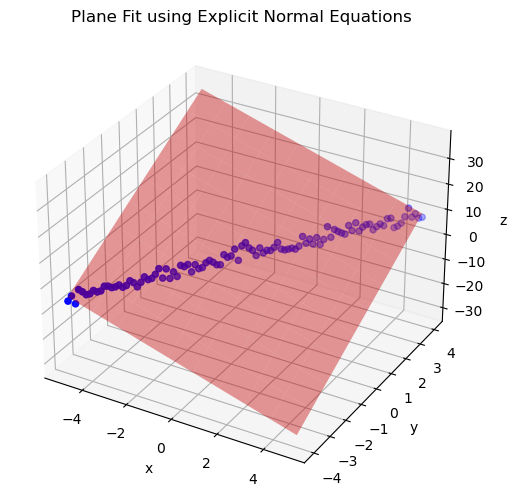

In [2]:
# --- Generate synthetic linear data in 3 dimensions ---
a_true, b_true, c_true = 1.0, 0.6, 2.5
x_data = np.linspace(-5, 5, 100)
y_data = np.linspace(-4, 4, 100)
noise_sigma = 1.6
z_data = a_true * x_data + b_true * y_data + c_true + rng.normal(0.0, noise_sigma, size=x_data.shape)




# Fit plane using explicit normal equations
a, b, c = fit_plane_normal_equation(x_data, y_data, z_data)
print(f"Fitted plane: z = {a:.4f} * x + {b:.4f} * y + {c:.4f}")

# Predictions
z_pred = a * x_data + b * y_data + c

# Mean Squared Error (goodness of fit)
mse = np.mean((z_data - z_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

# ----- Plot -----
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_data, y_data, z_data, color="blue", label="Data points")

# Build a mesh grid for the fitted plane surface
x_surf, y_surf = np.meshgrid(
    np.linspace(x_data.min(), x_data.max(), 10),
    np.linspace(y_data.min(), y_data.max(), 10),
    )
z_surf = a * x_surf + b * y_surf + c
ax.plot_surface(x_surf, y_surf, z_surf, color="red", alpha=0.4)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Plane Fit using Explicit Normal Equations")
plt.show()

## EXERCISES

1. Fit a plane for the following data and show a plot of the same.

   
   x = [-5, -9, -3, -4, 1, 0, -1, 2, 3, 4, 5]

   
   y = [-17, -14, -11, -8, -5, -2, 1, 4, 7, 10]


   z = [35, 25, 25, 18, 17, 10, 3, 0, -5, 4]


3. Let $k$ be the last digit of your Roll Number. Fit a plane for the following data and show a plot of the same.

   
   x = [-5, -9, -3, -4, 1, 0, -1, 2, 3, 4, 5]

   
   y = [-17, -14, -11, -8, -5, -2, 1, 4, 7, 10]


   z = [35+(k-3), 25, 25, 18+k, 17, 10+(k+1), 3, 0, -5+(k+2), 4]


z = 0.9028x + -1.7066y + 8.3104


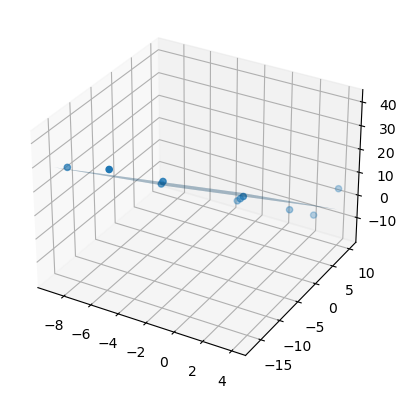

In [3]:
x_data = np.array([-5,-9,-3,-4,1,0,-1,2,3,4])
y_data = np.array([-17,-14,-11,-8,-5,-2,1,4,7,10])
z_data = np.array([35,25,25,18,17,10,3,0,-5,4])

a, b, c = fit_plane_normal_equation(x_data, y_data, z_data)

print(f"z = {a:.4f}x + {b:.4f}y + {c:.4f}")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_data, y_data, z_data)

xs, ys = np.meshgrid(
    np.linspace(x_data.min(), x_data.max(), 20),
    np.linspace(y_data.min(), y_data.max(), 20)
)

zs = a*xs + b*ys + c
ax.plot_surface(xs, ys, zs, alpha=0.4)
plt.show()

z = 1.1319x + -1.7861y + 11.9069


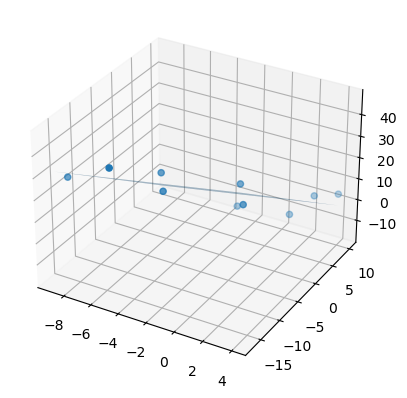

In [5]:
k = 9

x_data = np.array([-5,-9,-3,-4,1,0,-1,2,3,4])
y_data = np.array([-17,-14,-11,-8,-5,-2,1,4,7,10])

z_data = np.array([
    35+(k-3), 25, 25, 18+k, 17,
    10+(k+1), 3, 0, -5+(k+2), 4
])

a, b, c = fit_plane_normal_equation(x_data, y_data, z_data)

print(f"z = {a:.4f}x + {b:.4f}y + {c:.4f}")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_data, y_data, z_data)

xs, ys = np.meshgrid(
    np.linspace(x_data.min(), x_data.max(), 20),
    np.linspace(y_data.min(), y_data.max(), 20)
)

zs = a*xs + b*ys + c
ax.plot_surface(xs, ys, zs, alpha=0.4)
plt.show()